In [135]:
import networkx as nx
import torch
from torch_geometric.utils import from_networkx
import matplotlib.pyplot as plt
#from plotting             import plot_overlapping

karate = r"C:\Users\Microtec\Desktop\karate.txt"

In [136]:
G = nx.Graph()
node_labels = {}

with open(karate, "r") as f:
    for line in f:
        line = line.strip()
        
        if line.startswith('{'):
            continue
        
        #Nodes
        if '{' in line and ',' not in line.split()[0]:
            parts = line.split(maxsplit=1)
            node_id = int(parts[0])
            if  "Mr. Hi" in line:
                node_labels[node_id] = 0
            elif "Officer" in line:
                node_labels[node_id] = 1
            G.add_node(node_id)
            
        #Edges
        elif "," in line:
            left, _ = line.split("{",1)
            nodes = left.strip().split(",")
            if len(nodes) == 2:
                try:
                    u, v = int(nodes[0]), int(nodes[1])
                    G.add_edge(u, v)
                except:
                    pass
                
G = nx.convert_node_labels_to_integers(G)
            

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 34
Edges: 78


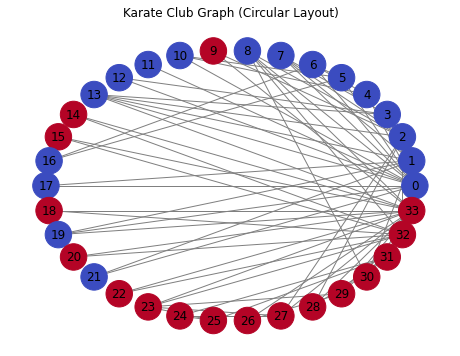

In [137]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(8, 6))

pos = nx.circular_layout(G)  # 👈 force circular layout

colors = [node_labels.get(n, -1) for n in G.nodes()]

nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    node_color=colors,
    cmap=plt.cm.coolwarm,
    node_size=700,
    edge_color="gray"
)

ax.set_title("Karate Club Graph (Circular Layout)")
plt.show()

In [138]:
from scipy.sparse import csgraph
from scipy.linalg import eigh
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

data = from_networkx(G)
adj = nx.to_numpy_array(G)
laplacian = csgraph.laplacian(adj, normed=True)

eigvals, eigvecs = eigh(laplacian)
k = 8

embedding = torch.tensor(eigvecs[:, 1:k+1], dtype=torch.float)
data.x = embedding


class NeuromapGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_clusters):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_clusters)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        
        # Soft assignment matrix S
        S = F.softmax(x, dim=1)
        return S


In [ ]:
def map_equation_loss(S, adj):
    deg = adj.sum(dim=1, keepdim=True)
    P = adj / deg.clamp(min=1e-10)

    pi = deg / deg.sum()
    F = torch.diag(pi.squeeze()) @ P

    C = S.T @ F @ S

    diag_C = torch.diag(C)
    q = 1.0 - torch.trace(C)

    q_m = torch.sum(C, dim=1) - diag_C
    m_exit = torch.sum(C, dim=0) - diag_C
    p_m = q_m + torch.sum(C, dim=0)

    def safe_log(p):
        return torch.log2(p + 1e-10)

    L = (
        q * safe_log(q)
        - torch.sum(q_m * safe_log(q_m))
        - torch.sum(m_exit * safe_log(m_exit))
        - torch.sum(pi.squeeze() * safe_log(pi.squeeze()))
        + torch.sum(p_m * safe_log(p_m))
    )

    return L

In [131]:
num_clusters = 34

model = NeuromapGCN(
    in_channels=data.x.shape[1],
    hidden_channels=16,
    num_clusters=num_clusters
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
adjTRUE = torch.tensor(nx.to_numpy_array(G), dtype=torch.float)
edge_index = data.edge_index

In [132]:
def train():
    model.train()
    optimizer.zero_grad()

    S = model(data.x, edge_index)
    loss = map_equation_loss(S, adjTRUE)

    loss.backward()
    optimizer.step()

    return loss.item()

for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 6.5249
Epoch 10, Loss: 6.5106
Epoch 20, Loss: 6.4470
Epoch 30, Loss: 6.3668
Epoch 40, Loss: 6.2220
Epoch 50, Loss: 5.9091
Epoch 60, Loss: 5.3949
Epoch 70, Loss: 4.7507
Epoch 80, Loss: 4.7100
Epoch 90, Loss: 4.7065


In [133]:
model.eval()
S = model(data.x, edge_index).detach()

labels = torch.argmax(S, dim=1).numpy()

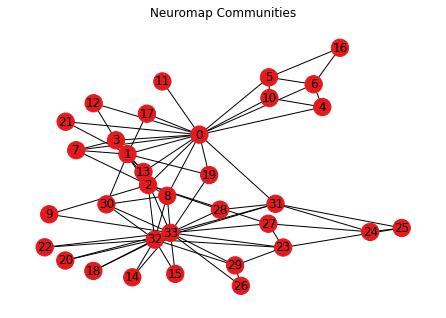

In [134]:
nx.draw(
    G,
    pos=nx.spring_layout(G, seed=42),
    node_color=labels,
    cmap=plt.cm.Set1,
    with_labels=True
)

plt.title("Neuromap Communities")
plt.show()

In [146]:
model = GCN(in_channels=data.x.shape[1], hidden_channels=16, out_channels=8)
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)
edge_index = data.edge_index
adjTRUE = torch.tensor(nx.to_numpy_array(G), dtype=torch.float)

def train():
    model.train()
    optimiser.zero_grad()
    z = model(data.x, edge_index)
    adjPRED = torch.sigmoid(z @ z.T)
    loss = F.binary_cross_entropy(adjPRED, adjTRUE)
    loss.backward()
    optimiser.step()
    return loss.item()

steps = 100
for epoch in range(steps):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:}")
        print(f"Loss: {loss:.4f}")
        print("================")

Epoch: 0
Loss: 0.6944
Epoch: 10
Loss: 0.6871
Epoch: 20
Loss: 0.6650
Epoch: 30
Loss: 0.6487
Epoch: 40
Loss: 0.6356
Epoch: 50
Loss: 0.6333
Epoch: 60
Loss: 0.6314
Epoch: 70
Loss: 0.6303
Epoch: 80
Loss: 0.6290
Epoch: 90
Loss: 0.6263


In [147]:
from sklearn.cluster import KMeans

model.eval()
z = model(data.x, edge_index).detach().numpy()
kmeans = KMeans(n_clusters=4, random_state=1234)
labels = kmeans.fit_predict(z)

print("Predicted Groups:")
print(labels)

Predicted Groups:
[0 0 0 0 2 2 2 0 1 1 2 0 0 0 1 1 2 0 1 0 1 0 1 3 3 3 1 3 1 1 1 3 1 1]


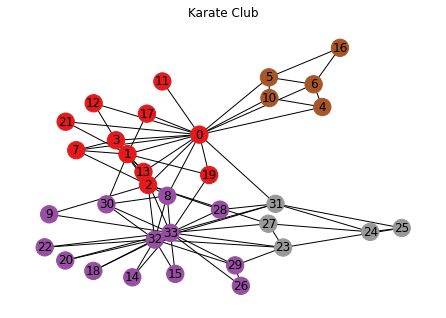

In [148]:
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=labels,
    cmap=plt.cm.Set1,
    with_labels=True
)

plt.title("Karate Club")
plt.show()

In [25]:
def add_small_ring(G, u, v, start_id):
    new_nodes = [start_id + i for i in range(4)]
    ring_nodes = [u, v] + new_nodes
    for i in range(6):
        G.add_edge(ring_nodes[i], ring_nodes[(i+1) % 6])
    return start_id + 4  # return next available node id

Pyr = nx.cycle_graph(12)

next_id = 12
next_id = add_small_ring(Pyr, 1, 2, next_id)
next_id = add_small_ring(Pyr, 5, 6, next_id)
next_id = add_small_ring(Pyr, 9, 10, next_id)


edges_to_add = [
    (8, 23),
    (11, 20),
    (0, 15),
    (3, 12),
    (4, 19),
    (7, 16),
]
Pyr.add_edges_from(edges_to_add)

next_node = max(Pyr.nodes()) + 1
new_nodes = [next_node, next_node + 1, next_node + 2]
Pyr.add_edge(new_nodes[0], 22)
Pyr.add_edge(new_nodes[0], 21)
Pyr.add_edge(new_nodes[1], 13)
Pyr.add_edge(new_nodes[1], 14)
Pyr.add_edge(new_nodes[2], 17)
Pyr.add_edge(new_nodes[2], 18)




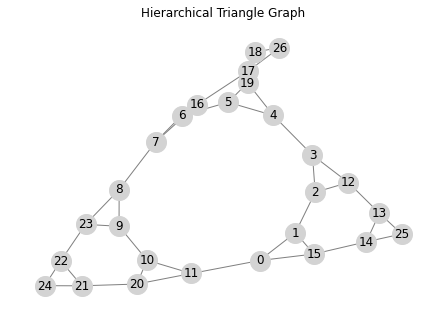

In [110]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(Pyr, seed=42)

nx.draw(
    Pyr,
    pos,
    with_labels=True,
    node_size=400,
    node_color="lightgray",
    edge_color="gray"
)

plt.title("Hierarchical Triangle Graph")
plt.show()

In [124]:
data = from_networkx(Pyr)
adj = nx.to_numpy_array(Pyr)
laplacian = csgraph.laplacian(adj, normed=True)

eigvals, eigvecs = eigh(laplacian)
k = 8

embedding = torch.tensor(eigvecs[:, 1:k+1], dtype=torch.float)
data.x = embedding

num_clusters = 27

model = NeuromapGCN(
    in_channels=data.x.shape[1],
    hidden_channels=16,
    num_clusters=num_clusters
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
adjTRUE = torch.tensor(nx.to_numpy_array(Pyr), dtype=torch.float)
edge_index = data.edge_index

Epoch 0, Loss: 13.7758


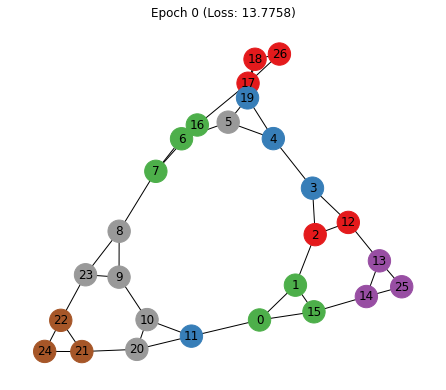

Epoch 10, Loss: 13.5625
Epoch 20, Loss: 12.5225
Epoch 30, Loss: 11.3230


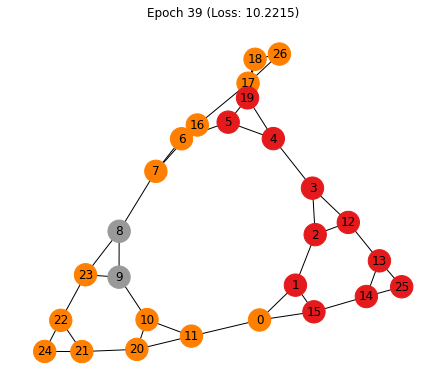

Epoch 40, Loss: 10.0401
Epoch 50, Loss: 8.2465
Epoch 60, Loss: 6.3913
Epoch 70, Loss: 5.7728


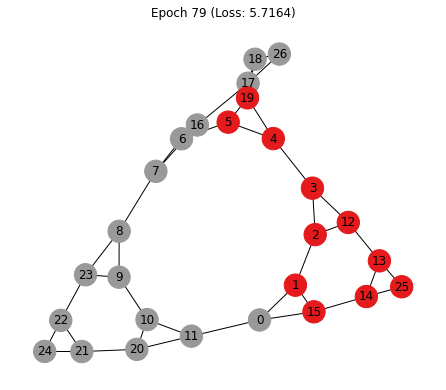

Epoch 80, Loss: 5.7127
Epoch 90, Loss: 5.6721
Epoch 100, Loss: 5.6076
Epoch 110, Loss: 5.5086


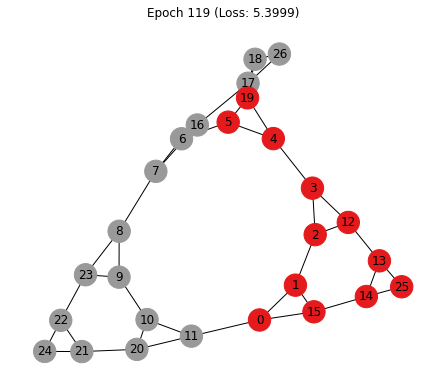

Epoch 120, Loss: 5.3876
Epoch 130, Loss: 5.2727
Epoch 140, Loss: 5.1886
Epoch 150, Loss: 5.1413


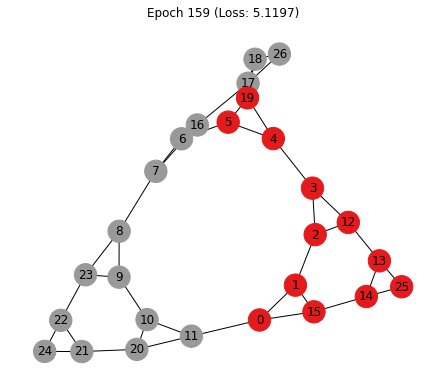

In [125]:
num_epochs = 160
num_plots = 5

# epochs where we plot (even spacing)
plot_epochs = set([
    int(i * (num_epochs - 1) / (num_plots - 1)) for i in range(num_plots)
])

for epoch in range(num_epochs):
    loss = train()

    # print every 10 epochs 
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

    # plot
    if epoch in plot_epochs:
        model.eval()
        with torch.no_grad():
            S = model(data.x, edge_index)
            labels = torch.argmax(S, dim=1).cpu().numpy()

        pos = nx.spring_layout(Pyr, seed=42)

        plt.figure(figsize=(6, 5))
        nx.draw(
            Pyr,
            pos,
            node_color=labels,
            cmap=plt.cm.Set1,
            with_labels=True,
            node_size=500
        )

        plt.title(f"Epoch {epoch} (Loss: {loss:.4f})")
        plt.show()


In [113]:
model.eval()
S = model(data.x, edge_index).detach()

labelsPyr = torch.argmax(S, dim=1).numpy()
print(labelsPyr.size)

27


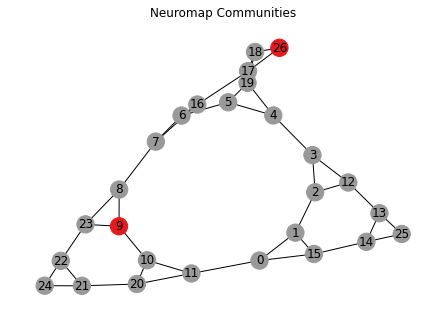

In [114]:
nx.draw(
    Pyr,
    pos=nx.spring_layout(Pyr, seed=42),
    node_color=labelsPyr,
    cmap=plt.cm.Set1,
    with_labels=True
)

plt.title("Neuromap Communities")
plt.show()

In [149]:
def compress_network(graph, community):
    """
    Compresses a graph based on a given community assignment.
    Args:
        graph: dict of node -> dict of neighbor -> weight
        community: dict of node -> community_id
    Returns:
        new_graph: dict of community_id, builds a new graph where each community is a node and edges represent aggregated flows between communities.
    """
    # Step 1: relabel communities
    # First we extract unique community IDs and create a mapping to new indices
    comm_ids = list(set(community.values()))
    # Reassign community labels to a contiquous range (0, 1, 2, ...) (makes indexing simpler)
    comm_map = {c: i for i, c in enumerate(comm_ids)}

    # Step 2: initialize new graph weights
    # Initialise a dictionary to hold the aggregated edge weights between communities
    edge_weights = {comm_map[c]: {} for c in comm_ids}

    # Step 3: aggregate flows
    # Loop through every node in original graph
    for node in graph:
        # Find the community index for this node
        ci = comm_map[community[node]]

        # Iterate over all outgoing edges of the node and aggregate weights into the new graph
        for neighbor, weight in graph[node].items():
            cj = comm_map[community[neighbor]]
            edge_weights[ci][cj] = edge_weights[ci].get(cj, 0) + weight

    # Step 4: build adjacency
    # Convert edge_weights into the desired format: dict of community_id -> list of (neighbor_community_id, weight)
    new_graph = {
        ci: [(cj, w) for cj, w in neighbors.items()]
        for ci, neighbors in edge_weights.items()
    }

    return new_graph


Compressed graph:
0 -> [(0, 46), (2, 4), (1, 8), (3, 2)]
1 -> [(0, 8), (1, 44), (3, 7)]
2 -> [(0, 4), (2, 12)]
3 -> [(3, 12), (1, 7), (0, 2)]


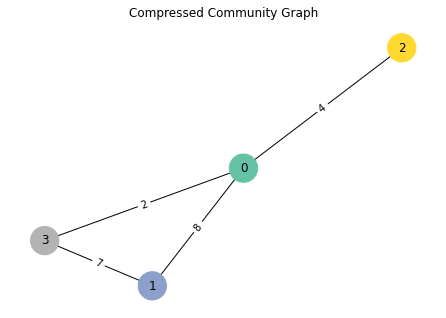

In [152]:
graph_dict = {
    node: {nbr: 1 for nbr in G.neighbors(node)}
    for node in G.nodes()
}

community = {node: int(labels[i]) for i, node in enumerate(G.nodes())}

compressed = compress_network(graph_dict, community)

print("Compressed graph:")
for k, v in compressed.items():
    print(k, "->", v)

G_compressed = nx.Graph()

for u, neighbors in compressed.items():
    for v, w in neighbors:
        if u != v:  # skip self-loops if desired
            G_compressed.add_edge(u, v, weight=w)

pos = nx.spring_layout(G_compressed, seed=42)

nx.draw(
    G_compressed,
    pos,
    with_labels=True,
    node_size=800,
    node_color=list(G_compressed.nodes()),
    cmap=plt.cm.Set2
)

edge_labels = nx.get_edge_attributes(G_compressed, 'weight')
nx.draw_networkx_edge_labels(G_compressed, pos, edge_labels=edge_labels)

plt.title("Compressed Community Graph")
plt.show()

In [160]:
import igraph as ig
import numpy as np

def compress_network_LAURA(g: ig.Graph, communities, verbose=False) -> tuple:
    """
    Implements Phase 2 of the infomap search algorithm. Compresses the network by
    collapsing each community into a single super-node and aggregating edge weights,
    with within-community edges resulting in self-loops.

    Args:
    g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
    communities (list[int] or np.ndarray): Community label for each node of g. Labels
        need not be 0-indexed or contiguous (e.g. after previous merge steps some 
        labels may be absent from the range).
    verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
    g_compressed (ig.Graph): Compressed graph with len(np.unique(communities)) nodes.
        Always weighted (aggregated weights stored as the "weight" edge attribute).
        Directedness matches the input graph. May contain self-loops.
    community_map (np.ndarray): Sorted array of the unique original community labels,
        where community_map[i] is the original label of super-node i in
        g_compressed. Because the array is sorted, np.searchsorted can
        cheaply convert original community labels to compressed-node indices.
    """
    communities = np.array(communities)

    # --- Get 0-indexed node IDs for communities -------------------------
    # The plan is to get a sorted list of the unique communities, and have the node
    # indices of the compressed graph correspond to the list indices of the corresponding
    # community in the sorted list. The list will be returned alongside the compressed Graph
    # to allow recovery of original community assignments
    unique_communities = np.unique(communities) # get all unique community labels, sorted
    n_communities = int(len(unique_communities)) # get number of communities

    # For each original node, get the position of its community label in the sorted
    # unique_communities array 
    node_to_compressed = np.searchsorted(unique_communities, communities)
    # basically contains for each node the index of the community instead of the community label
    # these indices will be the supernode indices of the compressed graph

    if verbose:
        print(f"Input graph has {n_communities} unique communities, {g.vcount()} nodes and {g.ecount()} edges.")


    # --- Build compressed edge list with aggregated weights -----------------
    # We'll basically build a graph with a number of nodes = number of communities
    # and then insert the correctly aggregated edges that we compute here
    if g.ecount() > 0: # if we have edges get the weights
        weights = np.array(
            g.es["weight"] if g.is_weighted() else np.ones(g.ecount()),
            dtype=np.float64
        )
        edges = np.array(g.get_edgelist(), dtype=np.int64) # build edgelist

        # map each start/endpoint to its compressed-graph node index
        # so basically instead of (starting node, ending node) we now have
        # the community indices (starting community, ending community)
        new_src = node_to_compressed[edges[:, 0]].astype(np.int64)  
        new_trg = node_to_compressed[edges[:, 1]].astype(np.int64)

        # Encode each (src, trg) pair as a single int64 key for O(E log E)
        # aggregation via np.unique instead of a Python dict loop.
        # with this, basically src = edge_key // n_communities, 
        # trg = edge_key % n_communities
        edge_keys = new_src * np.int64(n_communities) + new_trg
        # with this, any edges connecting the same communities a and b will have the same edge key
        # which we can then use to aggregate the weights

        # Sum weights of all edges that map to the same (src, trg) pair.
        # First, np.unique gives the unique keys and an inverse mapping; 
        unique_keys, inverse_idx = np.unique(edge_keys, return_inverse=True)
        # gets sorted unique edge keys, and a list containing for each edge_key (so for each edge)
        # in the original list the index of the key in the unique_keys list (inverse mapping)

        # np.add.at accumulates weights into the correct bucket in one vectorised pass.
        agg_weights = np.zeros(len(unique_keys), dtype=np.float64) # init array for edge weight aggregation
        np.add.at(agg_weights, inverse_idx, weights) 
        # adds the weights of each edge to the element in agg_weights whose index corresponds
        # to the inverse_idx of that edge, which is the same as the index of the unique keys
        # so for any edges connecting the same communities a and b (who will have the same 
        # edge_key, and thus the same inverse_idx), the weights are summed.

        # Decode integer keys back to (src, trg) pairs
        # keeping only the unique ones
        compressed_src = (unique_keys // n_communities).tolist() 
        compressed_trg = (unique_keys %  n_communities).tolist()
        new_edges = list(zip(compressed_src, compressed_trg)) 

    else:                       # original graph has no edges
        new_edges = []
        agg_weights = np.array([], dtype=np.float64)

    # --- Assemble the compressed igraph.Graph --------------------------------
    # self-loops from intra-community edges are explicitly required here and are handled
    # correctly by compute_description_length (they satisfy src_com == trg_com
    # and are therefore excluded from exit weights/flows by those helpers).
    # GOD I HOPE THAT'S ACTUALLY TRUE 

    if verbose:
        print(f"Creating compressed graph with {n_communities} nodes, {len(new_edges)} aggregated edges.")

    # create graph with # nodes = # communities of g
    g_compressed = ig.Graph(n=n_communities, directed=g.is_directed())  
    if new_edges: # if we have any edges to add
        g_compressed.add_edges(new_edges) # add the new aggregated edges
        g_compressed.es["weight"] = agg_weights.tolist() # assign them the aggregated weights
    
    # Return a copy so callers cannot accidentally mutate the internal array
    # we should be able to reconstruct the assignments from the unique_communites list
    # as it contains the mapping of og community -> compressed node index (== list index)
    return g_compressed, unique_communities.copy()

Description Length

In [153]:
import numpy as np
from collections import defaultdict
import math

# community dict from before
# community[node] = cluster_id

n_r = defaultdict(int)
m_rs = defaultdict(int)

for node, comm in community.items():
    n_r[comm] += 1

for u, v in G.edges():
    cu, cv = community[u], community[v]
    if cu <= cv:
        m_rs[(cu, cv)] += 1
    else:
        m_rs[(cv, cu)] += 1

N = G.number_of_nodes()
K = len(n_r)

L_model = N * math.log2(K)

L_edges = 0
for (r, s), m in m_rs.items():
    if m == 0:
        continue
        
    if r == s:
        denom = n_r[r] * (n_r[r] - 1) / 2
    else:
        denom = n_r[r] * n_r[s]
    
    L_edges += m * math.log2(denom / m)

L_original = L_model + L_edges

print("Description length (original):", L_original)

Description length (original): 226.4165079688703


In [154]:
# Total weight
W = sum(m_rs.values())

L_model_c = K * math.log2(K)

L_edges_c = 0
for (r, s), w in m_rs.items():
    if w > 0:
        L_edges_c += w * math.log2(W / w)

L_compressed = L_model_c + L_edges_c

print("Description length (compressed):", L_compressed)

Description length (compressed): 211.44091800886645


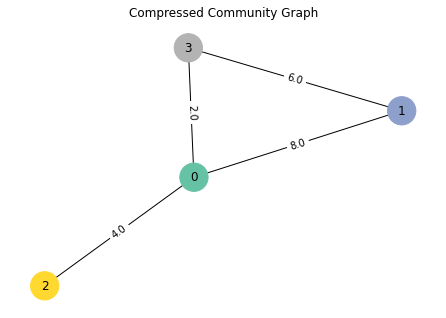

In [163]:
# Create empty igraph with same number of nodes
G_ig = ig.Graph()
G_ig.add_vertices(len(G.nodes()))

# Add edges (same indices as NetworkX)
G_ig.add_edges(list(G.edges()))

labels_array = [community[n] for n in G.nodes()]

compressedL = compress_network_LAURA(G_ig, labels_array)

g_comp_ig = compressedL[0]

G_compressedL = nx.Graph()

edges = g_comp_ig.get_edgelist()
weights = g_comp_ig.es["weight"] if g_comp_ig.is_weighted() else [1]*len(edges)

for (u, v), w in zip(edges, weights):
    if u != v:  # optional: skip self-loops
        G_compressedL.add_edge(u, v, weight=w)

pos = nx.spring_layout(G_compressedL, seed=42)

nx.draw(
    G_compressedL,
    pos,
    with_labels=True,
    node_size=800,
    node_color=list(G_compressedL.nodes()),
    cmap=plt.cm.Set2
)

edge_labels = nx.get_edge_attributes(G_compressedL, 'weight')
nx.draw_networkx_edge_labels(G_compressedL, pos, edge_labels=edge_labels)

plt.title("Compressed Community Graph")
plt.show()